In [1]:
#importing library
import pandas as pd

#importing the dataset
data = pd.read_csv("Titanic-Dataset.csv")

#reading first 5 rows of data
print(data.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [2]:
#firstly drop useless columns 
data.drop(['PassengerId','Name','Ticket'], axis=1, inplace=True)

In [3]:
#importing numpy library for cleaning the dtaset
import numpy as np

#checking missing values or nan values
print(data.isnull().sum())

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64


In [4]:
#handling missing values
#cabin = too many missing values, so drop 
#embarked = filling with mode(too frequent)
#age = filling with mean

data['Age'] = data['Age'].fillna(data['Age'].median())
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode())
data.drop('Cabin',axis=1, inplace=True)

In [5]:
#printing data's first 5 rows

print(data.head())

   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S


In [6]:
#converting categorial int numerical data

data['Sex'] = data['Sex'].map({'male':0,'female':1})
data['Embarked']= data['Embarked'].map({'S':0, 'C':1, 'Q': 2})

In [7]:
#survival vs gender

data.groupby('Sex')['Survived'].mean()

Sex
0    0.188908
1    0.742038
Name: Survived, dtype: float64

In [8]:
#survival vs Pclass

data.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

<Axes: xlabel='Age', ylabel='Count'>

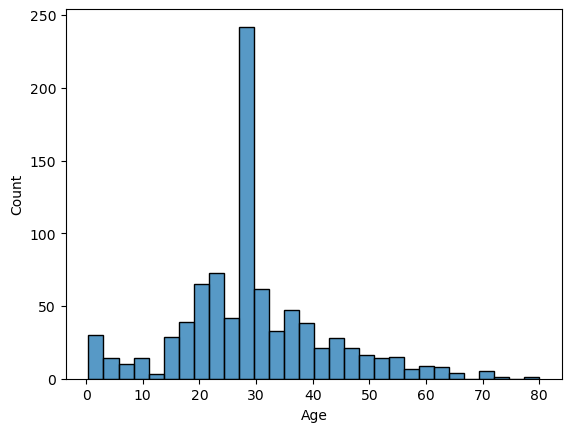

In [9]:
#age distribution

import seaborn as sns
sns.histplot(data['Age'], bins=30)

<Axes: >

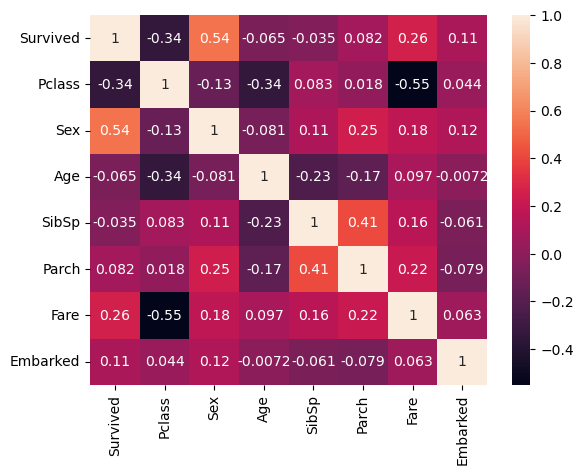

In [10]:
#correlation heatmap

sns.heatmap(data.corr(), annot=True)

<Axes: xlabel='Sex', ylabel='Survived'>

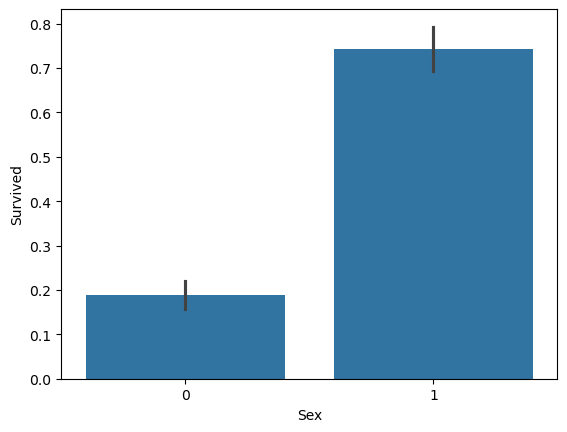

In [11]:
#countplots
sns.barplot(x='Sex', y='Survived', data=data)

<Axes: xlabel='Pclass', ylabel='Survived'>

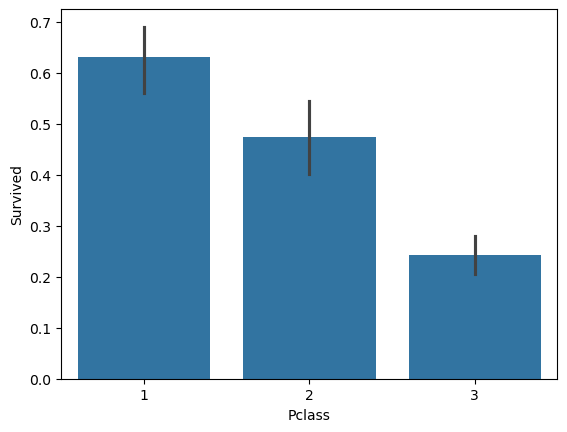

In [12]:
sns.barplot(x='Pclass', y='Survived', data=data)

In [13]:
#checking combination effect

data.groupby(['Sex','Pclass'])['Survived'].mean()

Sex  Pclass
0    1         0.368852
     2         0.157407
     3         0.135447
1    1         0.968085
     2         0.921053
     3         0.500000
Name: Survived, dtype: float64

In [14]:
#therefore survival influenced by gender, followed by passanger class.
#females had significantly higher survival rates across all classes
#among males survival droped sharply in lower class

In [20]:
data['FamilySize'] = data['SibSp']+ data['Parch']+1

In [21]:
data.groupby('FamilySize')['Survived'].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

In [25]:
#survival is highest for passengers with small families(1-4 members) 

In [30]:
#upgrading familySize column

def family_type(x):
    if x == 1:
        return 'Alone'
    elif x<=4:
        return 'Small'
    else:
        return 'Large'

data['FamilyType'] = data['FamilySize'].apply(family_type)

In [31]:
data.groupby('FamilyType')['Survived'].mean()

FamilyType
Alone    0.303538
Large    0.161290
Small    0.578767
Name: Survived, dtype: float64

In [32]:
#passengers travelling in small families had the highest survival rate,
#while those travelling alone or in large families had significantly lower chances of survival

In [33]:
data.groupby(['Sex','FamilyType'])['Survived'].mean()

Sex  FamilyType
0    Alone         0.155718
     Large         0.034483
     Small         0.321168
1    Alone         0.785714
     Large         0.272727
     Small         0.806452
Name: Survived, dtype: float64

In [ ]:
#Survival is highest among females travelling in small families had the lowest survival rates

In [34]:
data.groupby(['Sex','Pclass','FamilyType'])['Survived'].mean()

Sex  Pclass  FamilyType
0    1       Alone         0.333333
             Large         0.000000
             Small         0.444444
     2       Alone         0.097222
             Small         0.277778
     3       Alone         0.121212
             Large         0.037037
             Small         0.250000
1    1       Alone         0.970588
             Large         1.000000
             Small         0.964286
     2       Alone         0.906250
             Large         1.000000
             Small         0.928571
     3       Alone         0.616667
             Large         0.111111
             Small         0.561404
Name: Survived, dtype: float64

In [ ]:
#survival is influenced by gender the most, feamles survived significantly more than males, 
#espacially in Pclass 1 have highest survival rate, whereas
#males in large families even in Pclass 1 have almost no chances of survival